In [163]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro,levene,kruskal
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

### Data Exploration

In [208]:
data = pd.read_csv(r"C:\Users\Aditya Deshmukh\Datasets\aerofit_treadmill.csv")
df = data.copy()
df.head(5)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Product        180 non-null    str  
 1   Age            180 non-null    int64
 2   Gender         180 non-null    str  
 3   Education      180 non-null    int64
 4   MaritalStatus  180 non-null    str  
 5   Usage          180 non-null    int64
 6   Fitness        180 non-null    int64
 7   Income         180 non-null    int64
 8   Miles          180 non-null    int64
dtypes: int64(6), str(3)
memory usage: 12.8 KB


In [4]:
len(df)

180

In [5]:
df.shape

(180, 9)

In [45]:
data.dtypes

Product            str
Age              int64
Gender             str
Education        int64
MaritalStatus      str
Usage            int64
Fitness          int64
Income           int64
Miles            int64
dtype: object

In [44]:
df.dtypes

Product               str
Age               float64
Gender                str
Education        category
MaritalStatus         str
Usage               int64
Fitness          category
Income            float64
Miles               int64
AgeGroup         category
IncomeGroup      category
MilesGroup       category
dtype: object

In [7]:
df.isna().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

In [48]:
#unique values in each column

for i in df.columns:
  print(i,':',df[i].nunique())

Product : 3
Age : 25
Gender : 2
Education : 8
MaritalStatus : 2
Usage : 6
Fitness : 5
Income : 54
Miles : 28
AgeGroup : 3
IncomeGroup : 3
MilesGroup : 3


In [207]:
# Data Type Fixing


In [98]:
df['Miles'].unique()

array([112,  75,  66,  85,  47, 141, 103,  94, 113,  38, 188,  56, 132,
       169,  64,  53, 106,  95, 212,  42, 127,  74, 170,  21, 120, 200,
       140, 100,  80, 160, 180, 240, 150, 300, 280, 260, 360])

In [250]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,50],
                       labels=['Young','Adult','Old'])

df['IncomeGroup'] = pd.qcut(df['Income'], q=3,
                           labels=['Low','Medium','High'])

df['MilesGroup'] = pd.cut(
    df['Miles'],
    bins=[0, 50, 100, df['Miles'].max()],
    labels=['Low', 'Medium', 'High']
)

In [100]:
cat_cols = list(df.select_dtypes(include=["str","category"]).columns)
num_cols = list(df.select_dtypes(include=["int64","float64"]).columns)
print(f"categorical : {cat_cols}")
print(f"numerical : {num_cols}")

categorical : ['Product', 'Gender', 'Education', 'MaritalStatus', 'Fitness', 'AgeGroup', 'IncomeGroup', 'MilesGroup']
numerical : ['Age', 'Usage', 'Income', 'Miles']


In [101]:
for col in num_cols:
    ratio = df[col].nunique() / len(df)
    print(col, ratio)

Age 0.17777777777777778
Usage 0.03333333333333333
Income 0.34444444444444444
Miles 0.20555555555555555


In [102]:
print(df["Age"].describe())
print(df["Income"].describe())
print(df["Miles"].describe())

count    180.000000
mean      28.788889
std        6.943498
min       18.000000
25%       24.000000
50%       26.000000
75%       33.000000
max       50.000000
Name: Age, dtype: float64
count       180.000000
mean      53719.577778
std       16506.684226
min       29562.000000
25%       44058.750000
50%       50596.500000
75%       58668.000000
max      104581.000000
Name: Income, dtype: float64
count    180.000000
mean     103.194444
std       51.863605
min       21.000000
25%       66.000000
50%       94.000000
75%      114.750000
max      360.000000
Name: Miles, dtype: float64


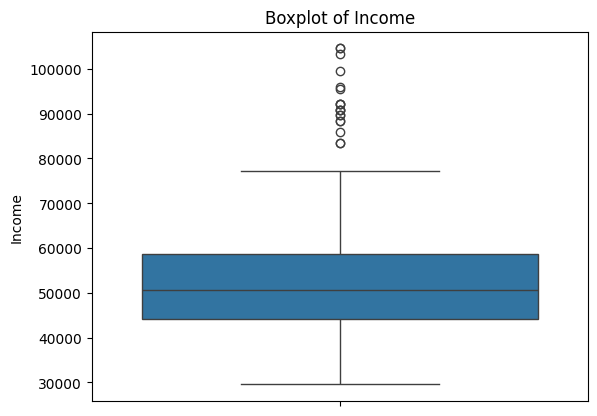

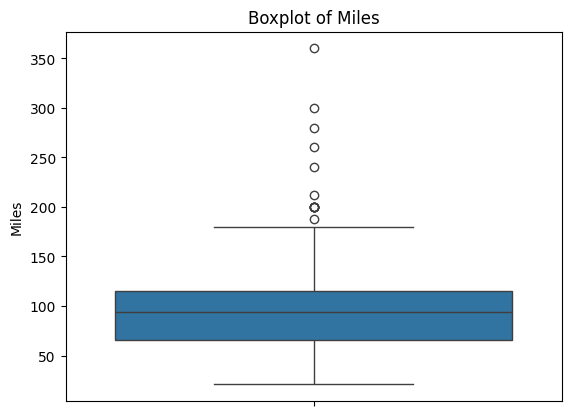

In [244]:
cont_cols = [ 'Income', 'Miles'] 

for col in cont_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [104]:
for col in cont_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

Age: 5 outliers
Income: 19 outliers
Miles: 13 outliers


In [105]:

for col in cont_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    
    df[col] = np.clip(df[col], lower, upper)

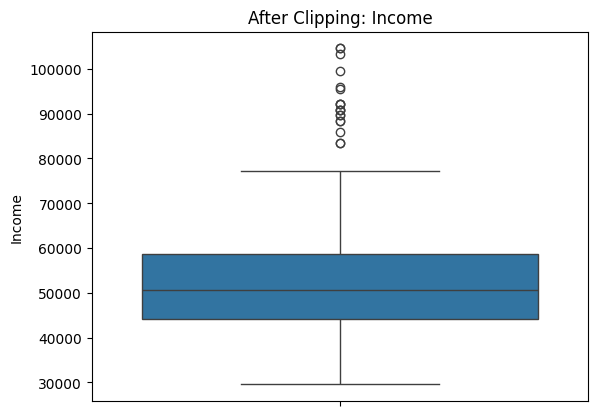

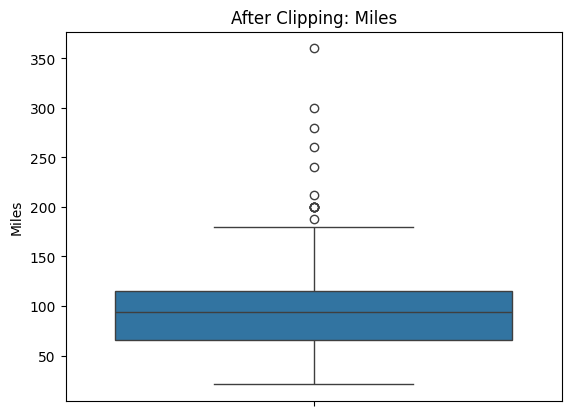

In [246]:
for col in cont_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'After Clipping: {col}')
    plt.show()

### Univariate and Bivariate Analysis

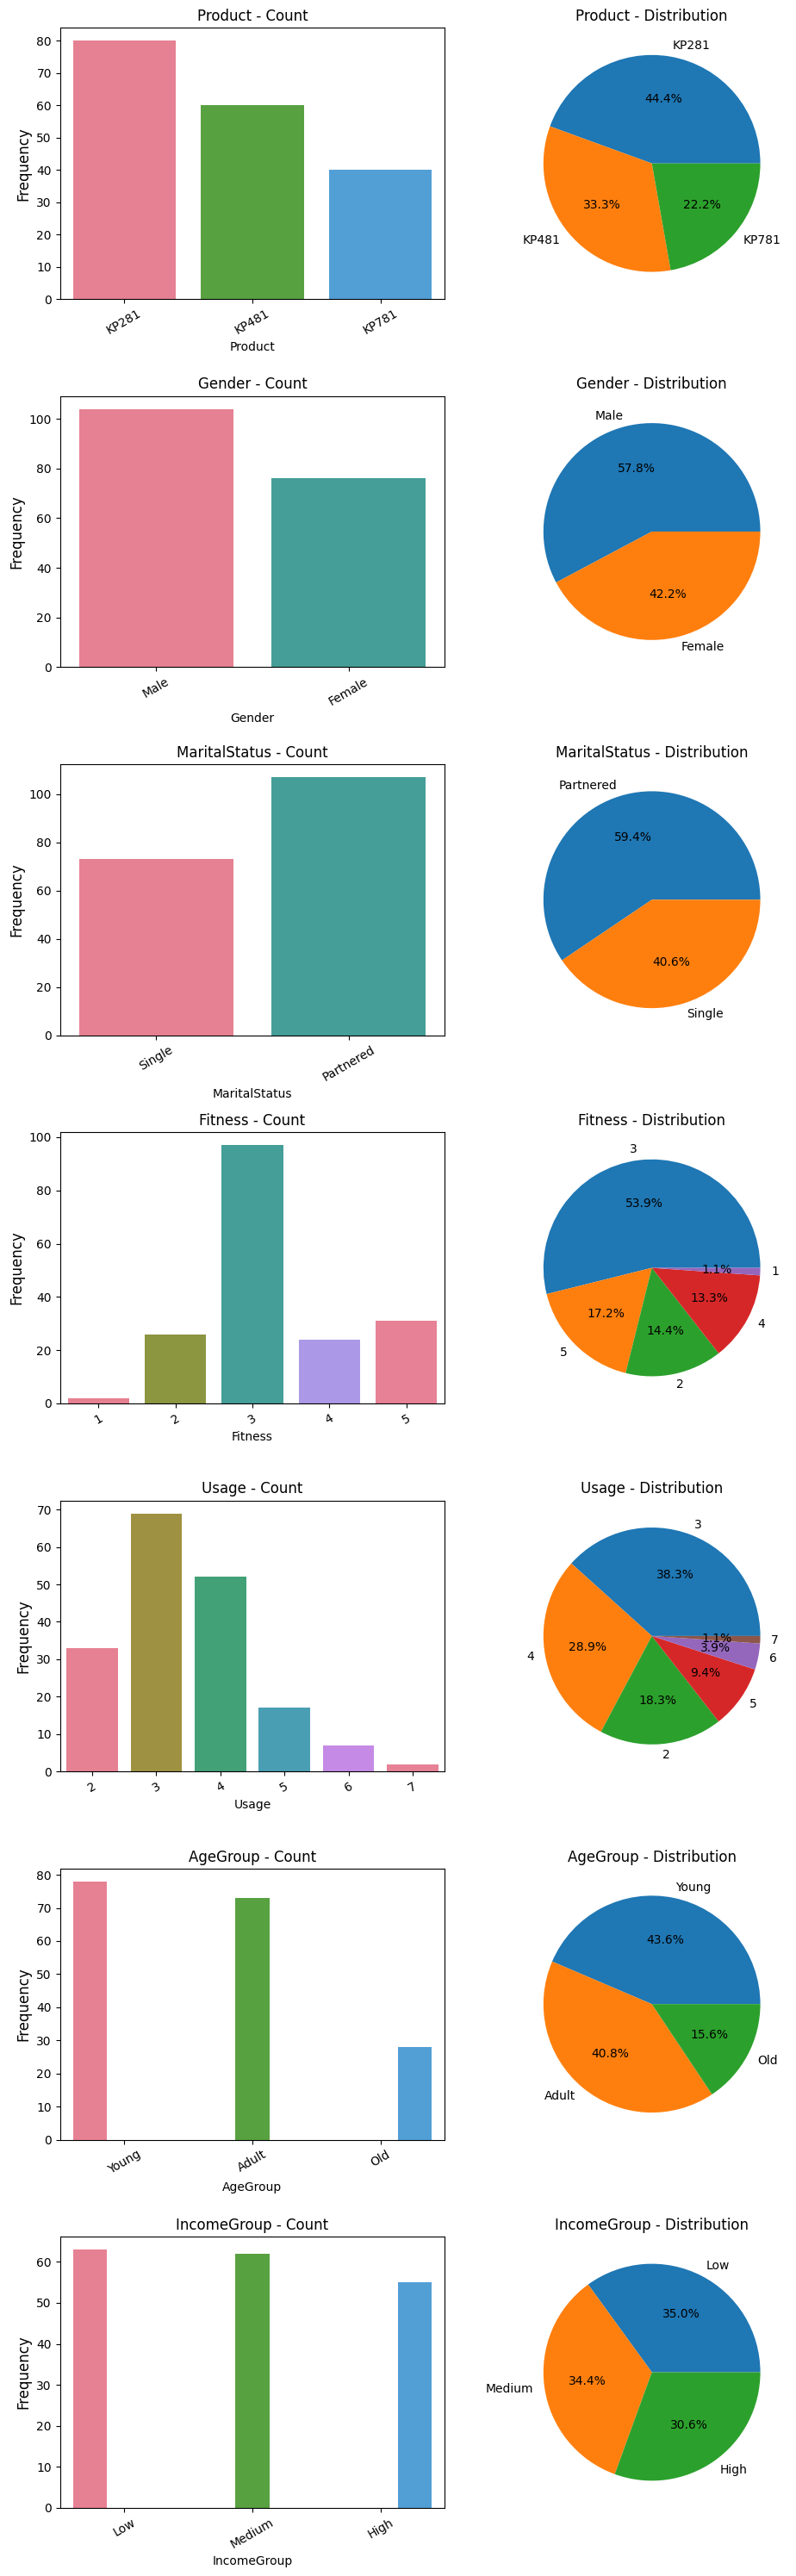

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid (7 rows, 2 columns)
fig, axes = plt.subplots(7, 2, figsize=(10, 30))

columns = [
    'Product',
    'Gender',
    'MaritalStatus',
    'Fitness',
    'Usage',
    'AgeGroup',
    'IncomeGroup'
]

for i, col in enumerate(columns):
    
    # BAR PLOT
    sns.countplot(
        x=col,
        data=df,
        ax=axes[i][0],
        hue = col,
        palette="husl",
        legend = False
    )
    axes[i][0].set_title(f"{col} - Count", fontsize=12)
    axes[i][0].set_ylabel("Frequency", fontsize=12)
    axes[i][0].tick_params(axis='x', rotation=30)
    
    # PIE CHART
    df[col].value_counts().plot.pie(
        autopct="%.1f%%",
        ax=axes[i][1],
        textprops={"fontsize": 10}
    )
    axes[i][1].set_title(f"{col} - Distribution", fontsize=12)
    axes[i][1].set_ylabel("")

plt.tight_layout()
plt.show()

1. KP281 is the most popular product with 44.44% of customers using it.

2. 58% of Males are using Aerofit Products

3. 59% Partnered people are using Aerofit Products

4. 54% of the customers have rated themselves 3 on Fitness. 5. Aerofit customers are using the treadmill mostly 3-4 days per week (67% customers). 6. 63% of Aerofit customers are Young Adults in the age group of 18-29.

7. 88% of Aerofit customers fall in Lower to Middle Income group i.e from 29K to 75K USD

#### Numerical

##### Age VS Product

###### Checking if "Age" effects the product purchased

In [22]:

groups_age = [df[df['Product']==p]['Age'] for p in df['Product'].unique()]



<Axes: xlabel='Product', ylabel='Age'>

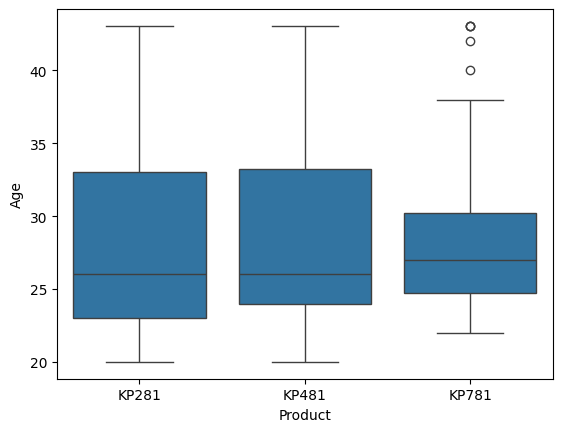

In [23]:
sns.boxplot(x='Product', y='Age', data=df)

In [ ]:
# we will use anova to check relation of age as nnumerical vs 3 categories

# we check if age fullfills the conditions for Anova

# 1. Check if the Data is Normally Distributed

# H0: Normally Distributed
# Ha: Not Normally Distributed

In [24]:
stat, p_value = shapiro(df['Age'])

print("Shapiro Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Data is NOT normally distributed")
else:
    print("Data is normally distributed")



Shapiro Statistic: 0.9126676113102775
p-value: 7.320430454227818e-09
Data is NOT normally distributed


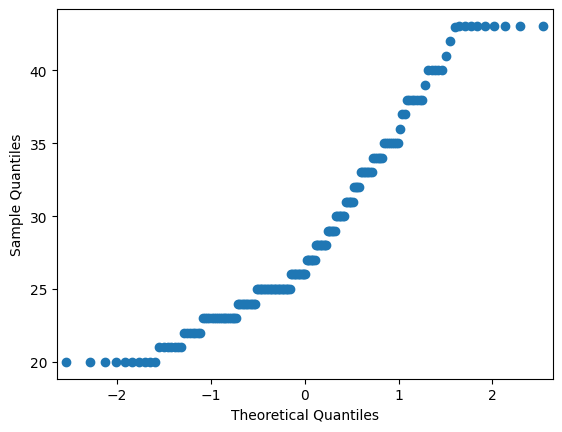

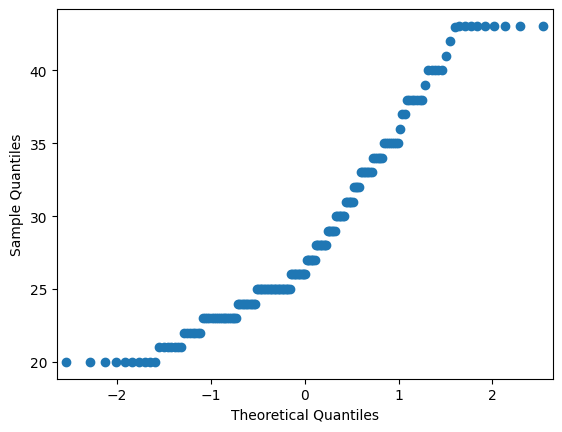

In [25]:
qqplot(data= df["Age"])

In [26]:
# 2. Check if data has equal Varience (Levenes)

# H0: Equal Variance
# Ha: Unequal Variance


In [27]:
stat, p_value = levene(*groups_age)

print("Levene Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Variances are NOT equal (assumption violated) , Reject H0")
else:
    print("Variances are equal (assumption satisfied) , Fail to Reject H0 ")

Levene Statistic: 0.39685263116651354
p-value: 0.6730299171752652
Variances are equal (assumption satisfied) , Fail to Reject H0 


In [28]:

# HYPOTHESIS 

# H0: Age does not effect product purchases
# Ha: Age effects the product purchased

In [29]:

f_stat,p_value = f_oneway(*groups_age)
print("f_stat : ",f_stat)
print("p_value : ",p_value)
alpha = 0.05
if p_value <alpha :
    print("Interpretation : Reject Ho")
else:
    print("Interpretation : Fail to Reject Ho")


f_stat :  0.0786580495578079
p_value :  0.9243882469107608
Interpretation : Fail to Reject Ho


In [30]:
# Krushkal- Wallis Test as Normality does not hold

# H0: Age does not effect product purchased
# Ha: Age effects the product purchased

In [31]:
stat, p_value = kruskal(*groups_age)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Age affects product purchased")
else:
    print("Fail to reject H0 → No significant effect")

Kruskal Statistic: 0.3589482984946862
p-value: 0.8357095543849073
Fail to reject H0 → No significant effect


##### Income VS Product

<Axes: xlabel='Product', ylabel='Income'>

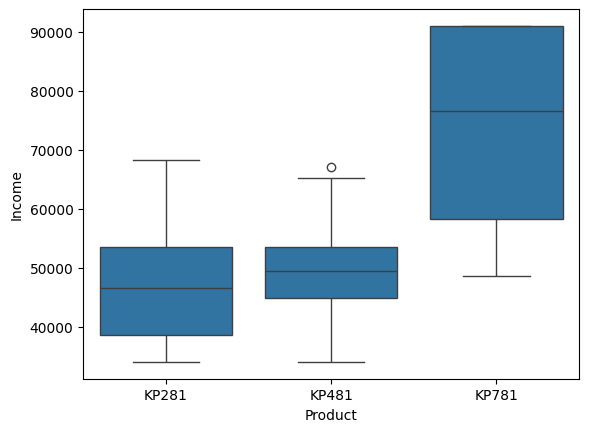

In [32]:
sns.boxplot(x='Product', y='Income', data=df)

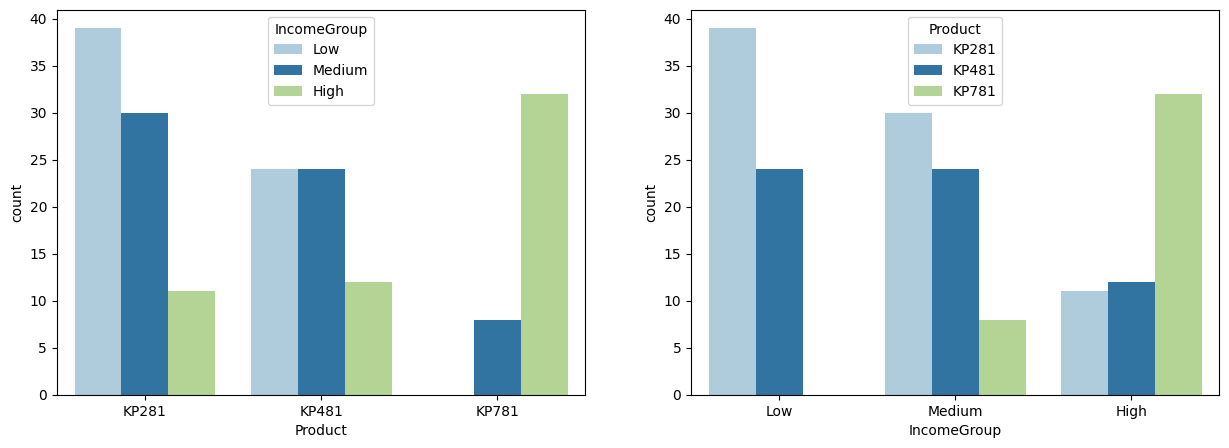

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='IncomeGroup', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='IncomeGroup', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. From the above plot we can see that there is not a much difference in mean for KP281,KP481 but a significant
difference in mean for KP781  signifies that only people with high income purchase KP781 Model

2. The people who belong to High income group are mostly using KP781

3. Low income people dominate KP281


In [33]:
# Lets Statistically confirm our Claim 
# we use anova as the comparison is numerical VS 3 Categories

In [34]:

groups_income = [df[df['Product']==p]['Income'] for p in df['Product'].unique()]


In [35]:
# 1. Check if the Data is Normally Distributed (shapiro test)

# H0: Normally Distributed
# Ha: Not Normally Distributed


stat, p_value = shapiro(df['Age'])

print("Shapiro Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Data is NOT normally distributed")
else:
    print("Data is normally distributed")


Shapiro Statistic: 0.9126676113102775
p-value: 7.320430454227818e-09
Data is NOT normally distributed


In [36]:
# 2. Check if data has equal Varience (Levenes test)

# H0: Equal Variance
# Ha: Unequal Variance


stat, p_value = levene(*groups_income)

print("Levene Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Variances are NOT equal (assumption violated) , Reject H0")
else:
    print("Variances are equal (assumption satisfied) , Fail to Reject H0 ")

Levene Statistic: 31.398799654130023
p-value: 2.1348459233712862e-12
Variances are NOT equal (assumption violated) , Reject H0


In [37]:
# Data not normally distributed using krushkal-wallis

# H0: Age does not effect product purchased
# Ha: Age effects the product purchased

stat, p_value = kruskal(*groups_income)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Income affects product purchased")
else:
    print("Fail to reject H0 → No significant effect")

Kruskal Statistic: 61.42963459221614
p-value: 4.578511777029354e-14
Reject H0 → Income affects product purchased


We reject the null hypothesis, meaning there is statistically significant evidence that Income affects product choice.

##### Usage VS Product

In [200]:
df.groupby(['Product','Usage']).size().reset_index(name='counts')

,Product,Usage,counts
0,KP281,2,19
1,KP281,3,37
2,KP281,4,22
3,KP281,5,2
4,KP481,2,14
5,KP481,3,31
6,KP481,4,12
7,KP481,5,3
8,KP781,3,1
9,KP781,4,18


<Axes: xlabel='Product', ylabel='Usage'>

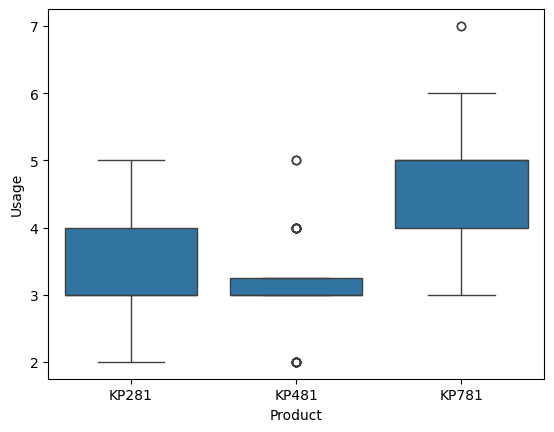

In [55]:
sns.boxplot(x='Product', y='Usage', data=df)

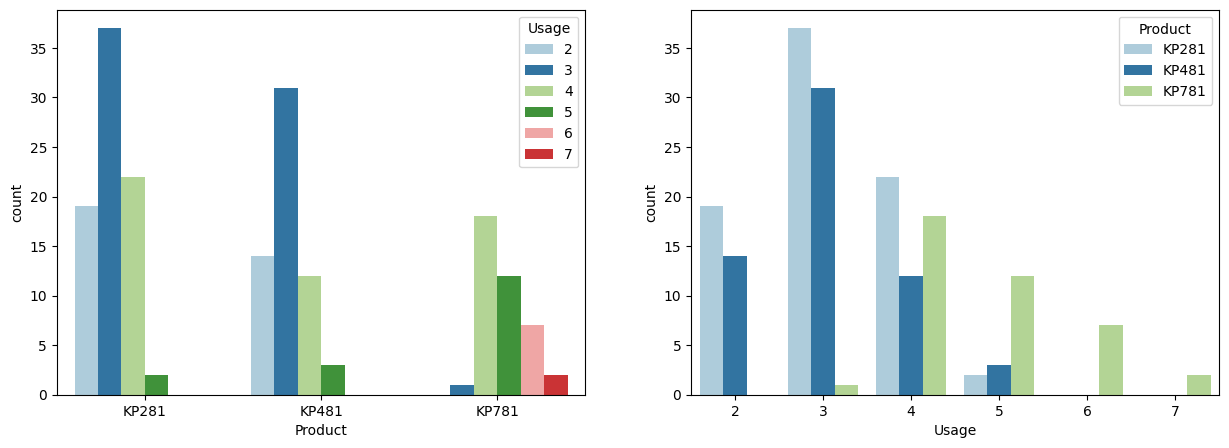

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='Usage', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='Usage', hue='Product', palette="Paired", ax=axes[1])

plt.show()

*Premium treadmill KP781 is preferred by high-frequency users, indicating that product choice is strongly influenced by usage intensity

1. **KP781** treadmill is the most used product, as we can see only this product has been used more between **4-7 days a week** suggests that this product is used by fitness enthusiasts and professionals.

2. **KP281** is the least used product where it's used mostly between 2-4 days a week.

3. **KP481** is a moderately used product.

In [61]:
groups_usage = [df[df['Product']==p]['Usage'] for p in df['Product'].unique()]

stat, p_value = kruskal(*groups_usage)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Usage affects product purchased")
else:
    print("Fail to reject H0 → No significant effect")

Kruskal Statistic: 68.7441335840811
p-value: 1.1814111370856494e-15
Reject H0 → Usage affects product purchased


##### Miles VS Product

In [192]:
df.groupby(['Product','MilesGroup']).size().reset_index(name='counts')

,Product,MilesGroup,counts
0,KP281,Low,12
1,KP281,Medium,50
2,KP281,High,18
3,KP481,Low,5
4,KP481,Medium,39
5,KP481,High,16
6,KP781,Medium,8
7,KP781,High,32


<Axes: xlabel='Product', ylabel='Miles'>

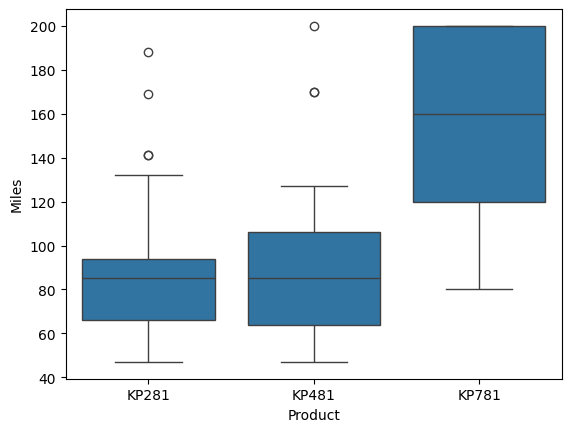

In [56]:
sns.boxplot(x='Product', y='Miles', data=df)

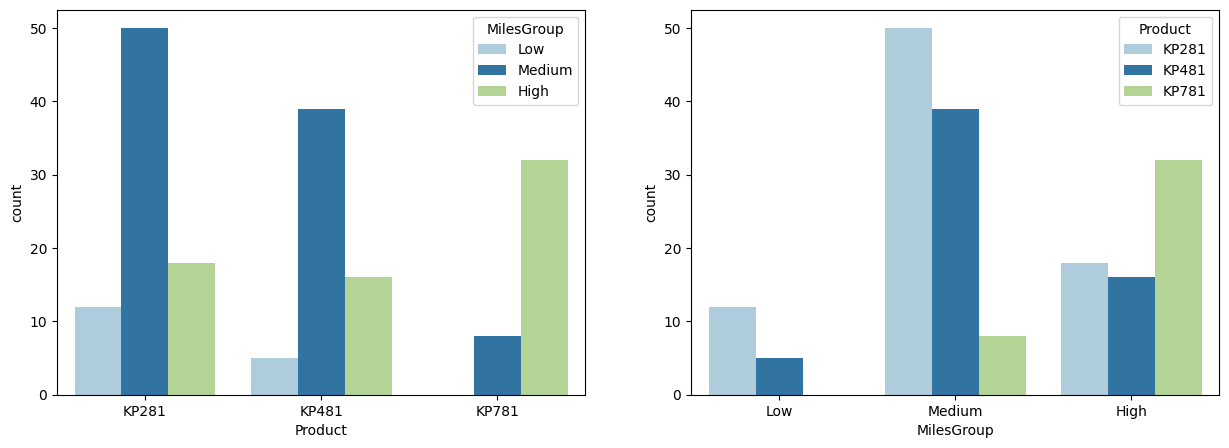

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='MilesGroup', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='MilesGroup', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. Higher-end treadmills are associated with higher mileage users, suggesting a clear segmentation 
between casual and performance-oriented customers

2. There is a strong alignment between income, usage frequency, and mileage, 
indicating that **KP781 targets a performance-driven, high-income customer segment**

3. Medium usage customers prefer KP281 than KP481

In [62]:
groups_miles = [df[df['Product']==p]['Miles'] for p in df['Product'].unique()]

stat, p_value = kruskal(*groups_usage)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Miles affects product purchased")
else:
    print("Fail to reject H0 → No significant effect")

Kruskal Statistic: 68.7441335840811
p-value: 1.1814111370856494e-15
Reject H0 → Miles affects product purchased


In [38]:
### Future Note : We cannot show the client this so make sure you make plots to explain all this to the client directly at last

#### How Categorical Columns effect Purchased

In [39]:
df[cat_cols].columns

Index(['Product', 'Gender', 'Education', 'MaritalStatus', 'Fitness',
       'AgeGroup', 'IncomeGroup', 'MilesGroup'],
      dtype='str')

##### Gender vs Product

In [197]:
df.groupby(['Product','Gender']).size().reset_index(name='counts')

,Product,Gender,counts
0,KP281,Female,40
1,KP281,Male,40
2,KP481,Female,29
3,KP481,Male,31
4,KP781,Female,7
5,KP781,Male,33


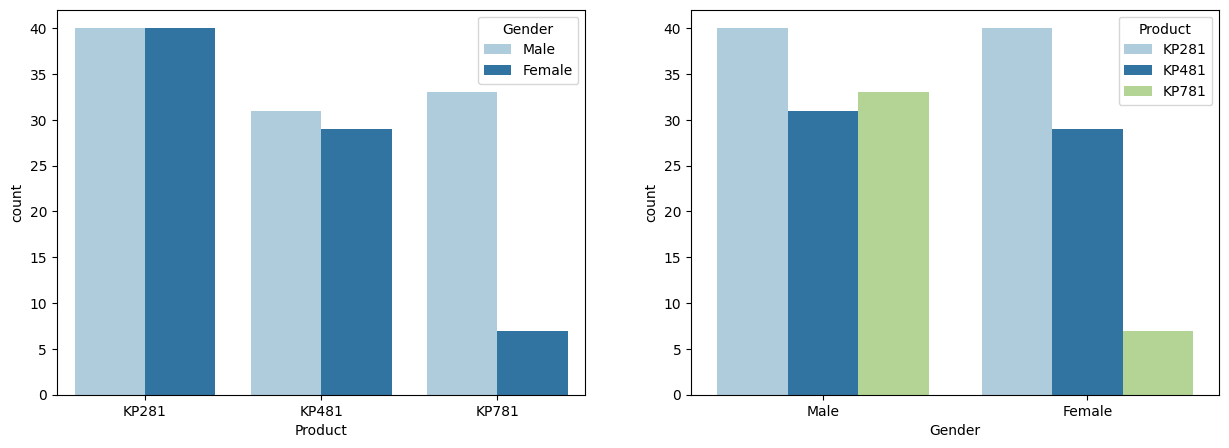

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='Gender', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='Gender', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. KP281 is popular among both men and women and is the most purchased among three

2. KP781 is *male dominant* product and female use it comparitively less

3. KP481 does not have much difference in popularity among men and women

In [78]:
# Lets confirm if the differences are statistically significant


# H0: Gender does not effect the Product choice
# Ha:  Gender effects the Product choice

G_P_matrix =pd.crosstab(df['Gender'],df['Product'])
G_P_matrix 



Product,KP281,KP481,KP781
Gender,,,
Female,40,29,7
Male,40,31,33


In [73]:
test_statistic, p_value, dof, expected_values = chi2_contingency(G_P_matrix)


print("Test statistic:", test_statistic)
print("p-value:", p_value)
print("dof", dof)
print("expected_values",expected_values)

alpha = 0.05

if(p_value < alpha):
  print("Reject H0 (Null Hypothesis),i.e.Gender and Product purchased are associated.")
else:
  print("Fail to Reject H0 (Null Hypothesis),i.e. Gender and Product purchased are not associated.")


Test statistic: 12.923836032388664
p-value: 0.0015617972833158714
dof 2
expected_values [[33.77777778 25.33333333 16.88888889]
 [46.22222222 34.66666667 23.11111111]]
Reject H0 (Null Hypothesis),i.e.Gender and Product purchased are associated.


#### MaritalStatus vs Product

In [199]:
df.groupby(['Product','MaritalStatus']).size().reset_index(name='counts')

,Product,MaritalStatus,counts
0,KP281,Partnered,48
1,KP281,Single,32
2,KP481,Partnered,36
3,KP481,Single,24
4,KP781,Partnered,23
5,KP781,Single,17


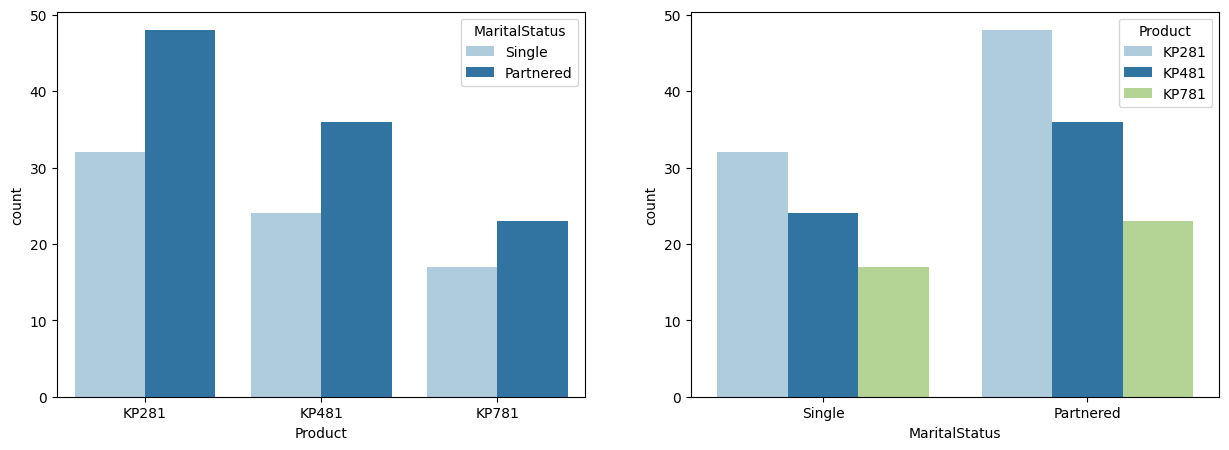

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='MaritalStatus', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='MaritalStatus', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. Partnered prefer KP281 more also the ratio remains the same for all three products

2. **Partnered buy overall more than single people**



In [79]:
# Lets confirm if the differences are statistically significant


# H0: Marital Status does not effect the Product choice
# Ha: Marital Status  effects the Product choice

M_P_matrix =pd.crosstab(df['MaritalStatus'],df['Product'])

M_P_matrix

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,48,36,23
Single,32,24,17


In [83]:
test_statistic, p_value, dof, expected_values = chi2_contingency(M_P_matrix)


print("Test statistic:", test_statistic)
print("p-value:", p_value)
print("dof", dof)
print("expected_values",expected_values)

alpha = 0.05

if(p_value < alpha):
  print("Reject H0 (Null Hypothesis),i.e.Marital Status and Product purchased are associated.")
else:
  print("Fail to Reject H0 (Null Hypothesis),i.e. Marital Status and Product purchased are not associated.")


Test statistic: 0.0806554858532839
p-value: 0.9604745988058153
dof 2
expected_values [[47.55555556 35.66666667 23.77777778]
 [32.44444444 24.33333333 16.22222222]]
Fail to Reject H0 (Null Hypothesis),i.e. Marital Status and Product purchased are not associated.


##### IncomeGroup vs Product

In [85]:
# Lets confirm if the differences are statistically significant

# H0: IncomeGroup does not effect the Product choice
# Ha: IncomeGroup  effects the Product choice

I_P_matrix =pd.crosstab(df['IncomeGroup'],df['Product'])

I_P_matrix

Product,KP281,KP481,KP781
IncomeGroup,,,
Low,39,24,0
Medium,30,24,8
High,11,12,32


In [86]:
test_statistic, p_value, dof, expected_values = chi2_contingency(I_P_matrix)


print("Test statistic:", test_statistic)
print("p-value:", p_value)
print("dof", dof)
print("expected_values",expected_values)

alpha = 0.05

if(p_value < alpha):
  print("Reject H0 (Null Hypothesis),i.e. IncomeGroup and Product purchased are associated.")
else:
  print("Fail to Reject H0 (Null Hypothesis),i.e. IncomeGroup and Product purchased are not associated.")


Test statistic: 63.51378299120235
p-value: 5.290052026042833e-13
dof 4
expected_values [[28.         21.         14.        ]
 [27.55555556 20.66666667 13.77777778]
 [24.44444444 18.33333333 12.22222222]]
Reject H0 (Null Hypothesis),i.e. IncomeGroup and Product purchased are associated.


 We reject the null hypothesis, indicating that there is a statistically significant 
association between income group and product purchased.



1. Income level is a key determinant of product choice. Customers in higher income groups show a strong preference for premium treadmills (KP781), while lower-income customers predominantly choose entry-level models (KP281). This suggests a **clear opportunity for targeted marketing and product positioning based on income segmentation.**

2. While income is the primary driver of product choice, gender also plays a significant role, particularly in the preference for premium treadmills, which are more popular among male customers.

#### AgeGroup VS Product

In [191]:
df.groupby(['Product','AgeGroup']).size().reset_index(name='counts')

,Product,AgeGroup,counts
0,KP281,Young,34
1,KP281,Adult,32
2,KP281,Old,14
3,KP481,Young,28
4,KP481,Adult,24
5,KP481,Old,8
6,KP781,Young,17
7,KP781,Adult,17
8,KP781,Old,6


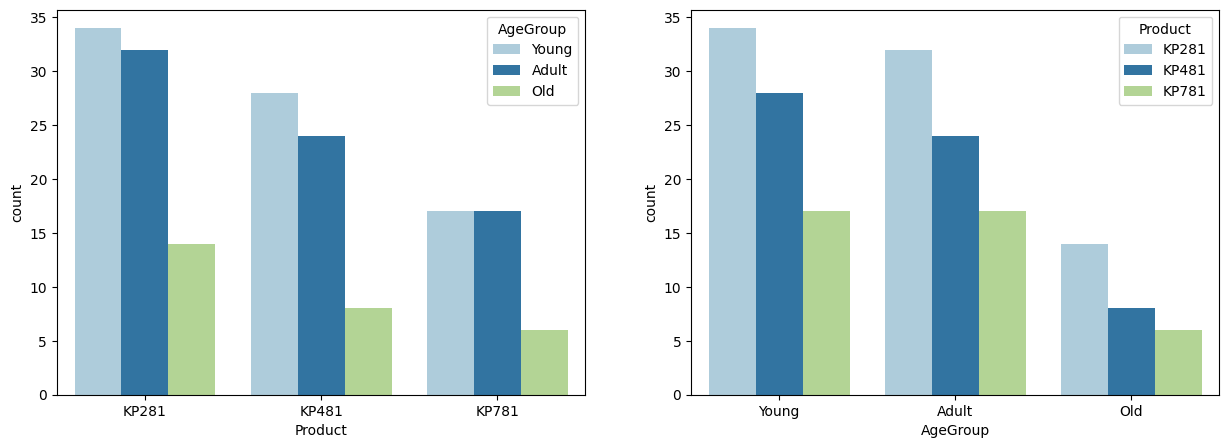

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='AgeGroup', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='AgeGroup', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. Old-Age Adults [40-50 years] are using all the 3 products almost equally.
   
2. Middle-Aged Adults [30-39 years] are using the KP281 and KP481 product almost equal
   
3. KP281 is the most popular choice among Young Adults [18-29] years

In [87]:
# Lets confirm if the differences are statistically significant

# H0: IncomeGroup does not effect the Product choice
# Ha: IncomeGroup  effects the Product choice

A_P_matrix =pd.crosstab(df['AgeGroup'],df['Product'])

A_P_matrix

Product,KP281,KP481,KP781
AgeGroup,,,
Young,33,28,17
Adult,32,24,17
Senior,14,8,6


In [89]:
test_statistic, p_value, dof, expected_values = chi2_contingency(A_P_matrix)


print("Test statistic:", test_statistic)
print("p-value:", p_value)
print("dof", dof)
print("expected_values",expected_values)

alpha = 0.05

if(p_value < alpha):
  print("Reject H0 (Null Hypothesis),i.e. AgeGroup and Product purchased are associated.")
else:
  print("Fail to Reject H0 (Null Hypothesis),i.e. AgeGroup and Product purchased are not associated.")


Test statistic: 0.6739422444403366
p-value: 0.954503066379049
dof 4
expected_values [[34.42458101 26.1452514  17.4301676 ]
 [32.21787709 24.46927374 16.31284916]
 [12.3575419   9.38547486  6.25698324]]
Fail to Reject H0 (Null Hypothesis),i.e. AgeGroup and Product purchased are not associated.


We fail to reject the null hypothesis, indicating that there is no statistically 
significant evidence that marital status influences product choice.

#### Product VS Fitness

In [209]:

df.groupby('Product').agg({'Age':'size', 'Fitness': 'mean'}).rename(columns={"Age": "count", "Fitness" : "Avg_score" })

,count,Avg_score
Product,,
KP281,80,2.9625
KP481,60,2.9000
KP781,40,4.6250


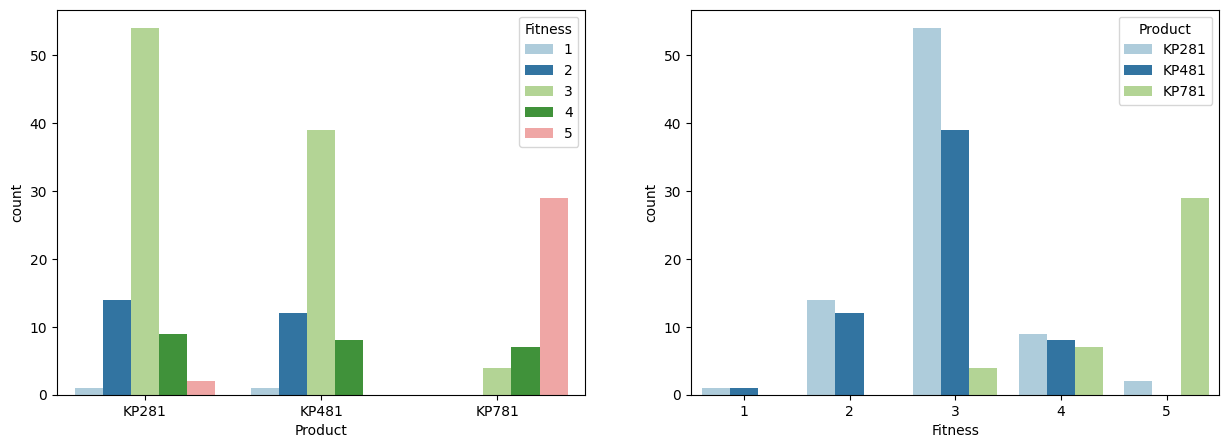

In [211]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='Fitness', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='Fitness', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. **KP781** is used by people who have given themselves the fitness rating 5 and avg rating is 4.625 which means KP781 is used by people who are professionals or fitness enthisiats

2. **KP281** and **KP481** have almost same fitness rating with **KP481** being a bit lower

#### Product VS Education

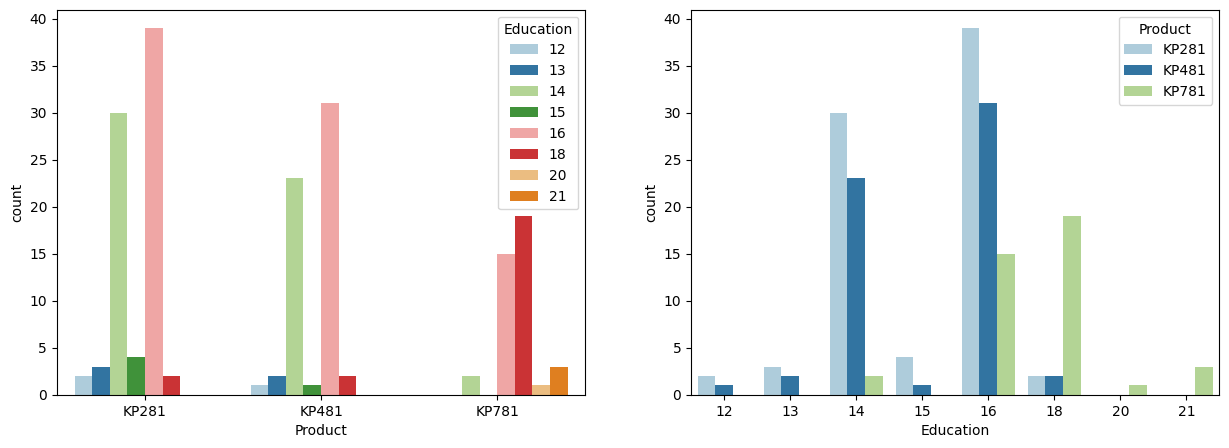

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Product', hue='Education', palette="Paired", ax=axes[0]) 
sns.countplot(data = df, x='Education', hue='Product', palette="Paired", ax=axes[1])

plt.show()

1. KP7821 is being purchased mostly by people above 16 years of experience

#### Marital Status and Fitness/Usage

In [214]:
df.groupby(['MaritalStatus', 'Usage']).size().reset_index(name='counts')

,MaritalStatus,Usage,counts
0,Partnered,2,22
1,Partnered,3,40
2,Partnered,4,29
3,Partnered,5,9
4,Partnered,6,5
5,Partnered,7,2
6,Single,2,11
7,Single,3,29
8,Single,4,23
9,Single,5,8


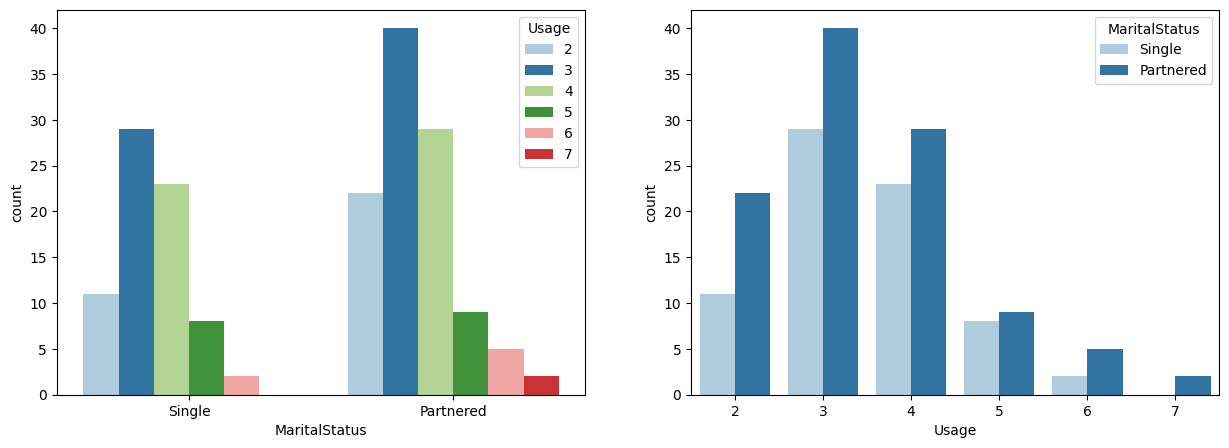

In [224]:
# plotting a count plot

fig,axes =  plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x= 'MaritalStatus', hue= 'Usage', palette = "Paired", ax=axes[0])
sns.countplot(data=df, x= 'Usage', hue= 'MaritalStatus', palette = "Paired", ax=axes[1])
plt.show()


In [229]:
print("Average Rating between 'Single' and 'Partnered' ")

df.groupby(['MaritalStatus']).agg({'Age' : 'size', 'Fitness': 'mean'}).rename(columns={'Age':'count','Fitness': 'Avg_score'})


Average Rating between 'Single' and 'Partnered' 


,count,Avg_score
MaritalStatus,,
Partnered,107,3.271028
Single,73,3.369863


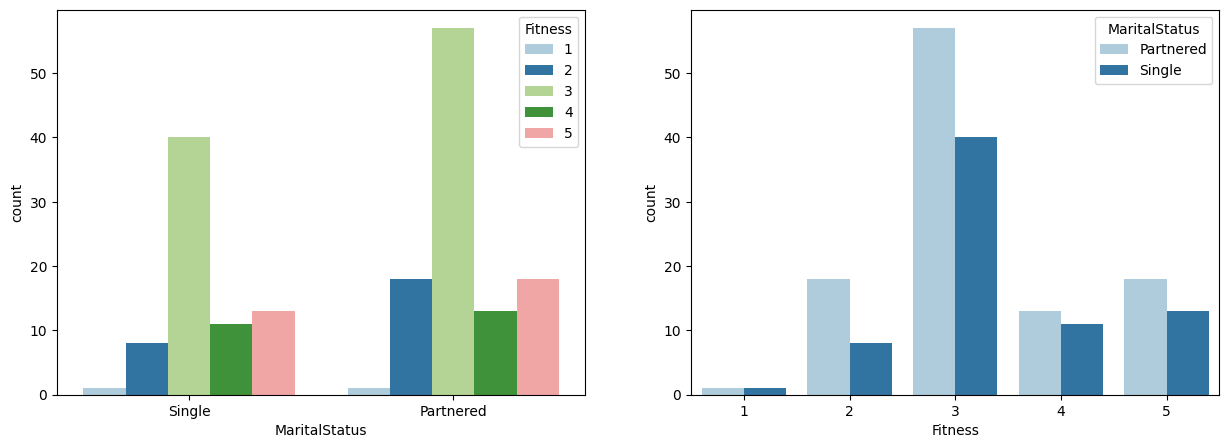

In [223]:
fig,axes =  plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x= 'MaritalStatus', hue= 'Fitness', palette = "Paired", ax=axes[0])
sns.countplot(data=df, x= 'Fitness', hue= 'MaritalStatus', palette = "Paired", ax=axes[1])
plt.show()

**Insights:**
1. Partnered customers are using Aerofit products more than single customers
2. Single have slightly more fitness score than partnered



#### Gender and Fitness/Usage

In [231]:
df.groupby(['Gender','Usage']).size().reset_index(name='count')

,Gender,Usage,count
0,Female,2,20
1,Female,3,33
2,Female,4,14
3,Female,5,7
4,Female,6,2
5,Male,2,13
6,Male,3,36
7,Male,4,38
8,Male,5,10
9,Male,6,5


In [234]:
print("Average Rating between 'Single' and 'Partnered' ")

df.groupby(['Gender']).agg({'Age' : 'size', 'Fitness': 'mean'}).rename(columns={'Age':'count','Fitness': 'Avg_score'})


Average Rating between 'Single' and 'Partnered' 


,count,Avg_score
Gender,,
Female,76,3.026316
Male,104,3.519231


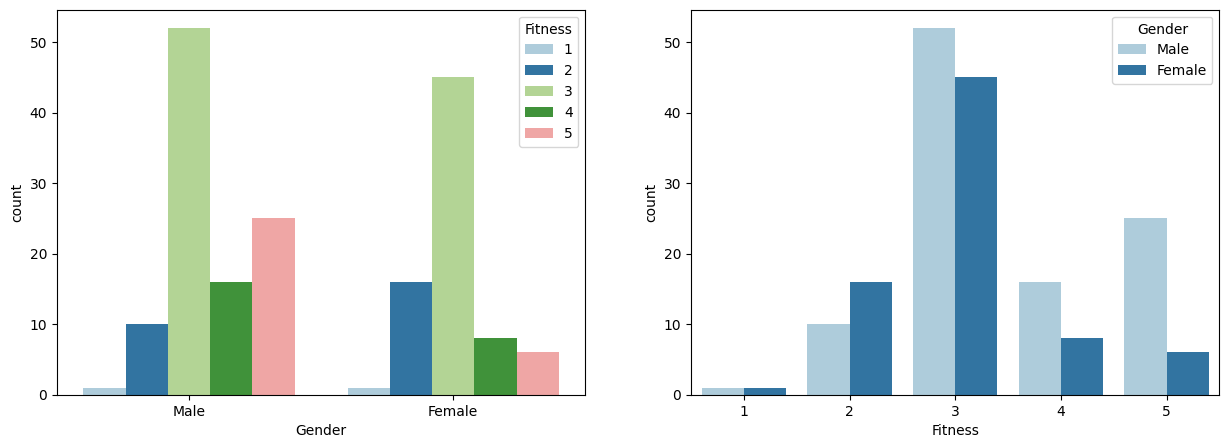

In [235]:
# plotting a countplot

fig,axes =  plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x= 'Gender', hue= 'Fitness', palette = "Paired", ax=axes[0])
sns.countplot(data=df, x= 'Fitness', hue= 'Gender', palette = "Paired", ax=axes[1])
plt.show()

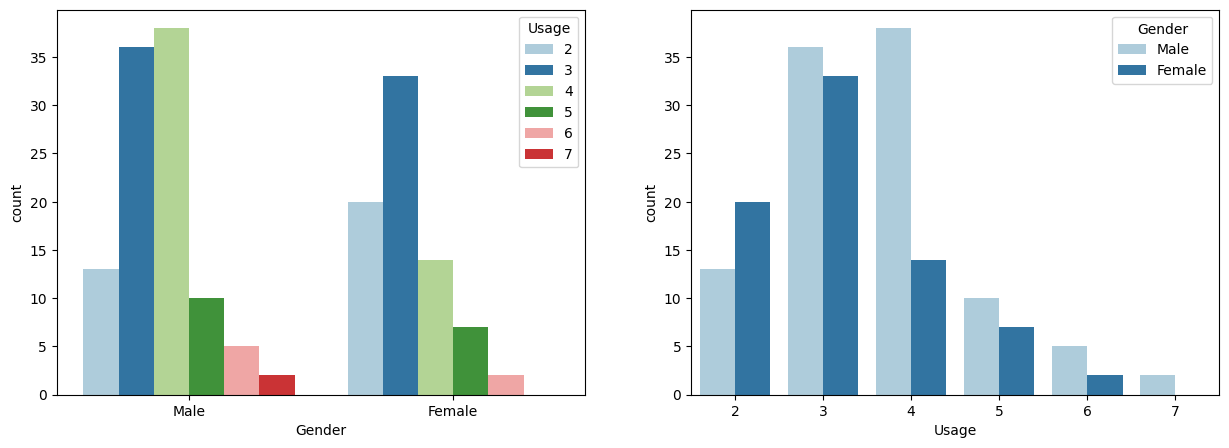

In [233]:
# plotting a countplot

fig,axes =  plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x= 'Gender', hue= 'Usage', palette = "Paired", ax=axes[0])
sns.countplot(data=df, x= 'Usage', hue= 'Gender', palette = "Paired", ax=axes[1])
plt.show()

**Insights:** 

    - Males have more fitness score compared to females
    - Males use Aerofit products more than females per week



### Representing Probability

In [130]:
overall_prob= df['Product'].value_counts(normalize=True)

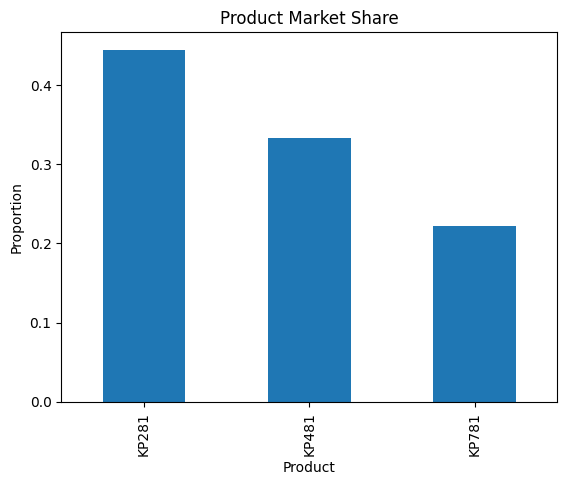

In [212]:
overall_prob.plot(kind='bar')
plt.title("Product Market Share")
plt.ylabel("Proportion")
plt.show()




In [142]:
# Function for plotting Conditional Probability

def plot_conditional(df, feature, target='Product'):
    import pandas as pd
    import matplotlib.pyplot as plt
    
    ct = pd.crosstab(df[feature], df[target], normalize='index')
    
    ct.plot(kind='bar', stacked=True)
    plt.title(f"{target} Distribution by {feature}")
    plt.ylabel("Proportion")
    plt.legend(title=target)
    plt.show()

In [148]:
pd.crosstab(df['IncomeGroup'], df['Product'], normalize='index') # P(Product | Feature) Conditional Probability

Product,KP281,KP481,KP781
IncomeGroup,,,
Low,0.619048,0.380952,0.000000
Medium,0.483871,0.387097,0.129032
High,0.200000,0.218182,0.581818


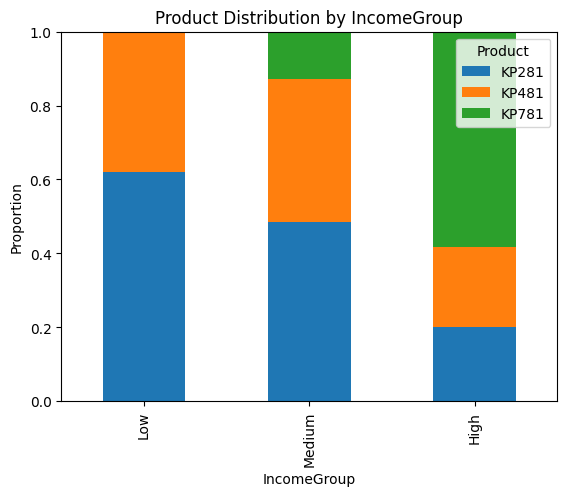

In [143]:
plot_conditional(df, 'IncomeGroup')

1. Low-income customers show a strong preference for KP281 (62%), with zero adoption of the premium KP781, indicating that affordability is a key constraint in product selection.

2. Medium-income customers exhibit a relatively balanced distribution between KP281 (48%) and KP481 (39%), with limited adoption of KP781 (13%), suggesting a transition segment that is partially price-sensitive but beginning to explore higher-end options.

3. High-income customers strongly prefer the premium model KP781 (58%), with significantly lower preference for entry-level products, indicating that higher purchasing power directly drives premium product adoption.

In [151]:
pd.crosstab(df['Gender'], df['Product'], normalize='index') # P(Product | Feature)

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


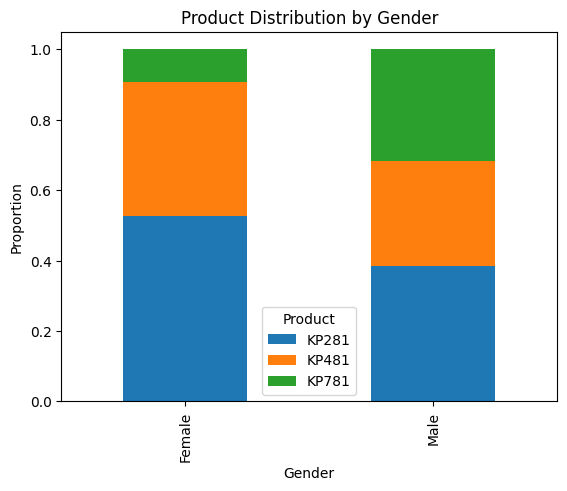

In [145]:
plot_conditional(df, 'Gender')


1. Female customers show a strong preference for entry-level and mid-tier treadmills, with 53% purchasing KP281 and only 9% opting for the premium        KP781, indicating lower adoption of high-end models

2. Male customers exhibit a significantly higher preference for the premium treadmill KP781 (32%) compared to females (9%), suggesting a stronger         inclination toward advanced or performance-oriented products.

**While both genders purchase entry-level products, male customers are over three times more likely than female customers to purchase the premium        treadmill KP781.**

*Recommendation* :

Marketing strategies for premium treadmills (KP781) should focus more on male customers, while entry-level and mid-tier products can be targeted more broadly across both genders, especially females.

In [193]:
pd.crosstab(df['AgeGroup'], df['Product'], normalize='index') 

Product,KP281,KP481,KP781
AgeGroup,,,
Young,0.430380,0.354430,0.215190
Adult,0.438356,0.328767,0.232877
Old,0.500000,0.285714,0.214286


1. Product preference remains relatively consistent across age groups, with KP281 being the most preferred product in all segments

Age does not appear to be a key driver of product selection, as purchasing patterns remain consistent across young, adult, and senior customers. This suggests that product choice is more influenced by factors such as income and usage rather than age.

In [146]:
pd.crosstab(df['MilesGroup'], df['Product'], normalize='index')

Product,KP281,KP481,KP781
MilesGroup,,,
Low,0.705882,0.294118,0.000000
Medium,0.515464,0.402062,0.082474
High,0.272727,0.242424,0.484848


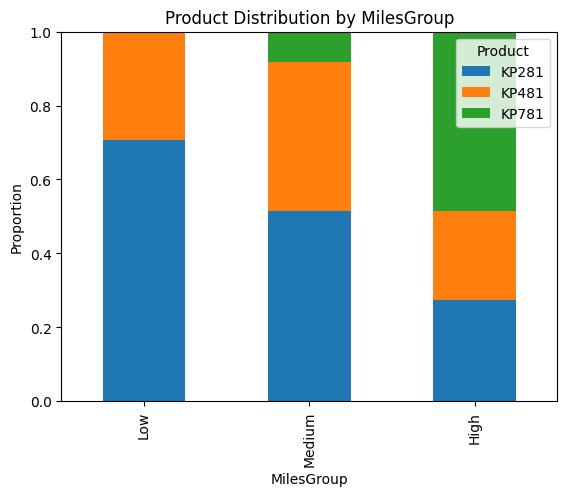

In [147]:
plot_conditional(df, 'MilesGroup')

1. Low-mileage users overwhelmingly prefer KP281 (71%), with zero adoption of KP781, 
*indicating that casual users strongly favor entry-level treadmills*

2. Medium-mileage users show a balanced preference between KP281 **(52%)** and KP481 **(40%)**, with minimal adoption of KP781 (8%), suggesting a transitional segment gradually moving toward higher-end products.

3. High-mileage users show a strong preference for the premium treadmill KP781 **(48%)**, with significantly reduced reliance on entry-level models, *indicating that higher activity levels drive demand for advanced equipment*.

Premium treadmill adoption is strongly driven by both financial capacity and usage intensity, with high-income, high-mileage users forming the core customer segment for KP781.

*Usage intensity, as measured by mileage, is a key behavioral driver of product choice, with higher-mileage users requiring more advanced treadmills, making them more likely to invest in premium models.*


In [124]:
pd.crosstab(df['MaritalStatus'], df['Product'], normalize='index')

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,0.448598,0.336449,0.214953
Single,0.438356,0.328767,0.232877


Almost similar weak indicator

##### Reverse conditional for customer profiling

In [154]:
def plot_reverse(df, feature, target='Product'):
    import pandas as pd
    import matplotlib.pyplot as plt
    
    ct = pd.crosstab(df[feature], df[target], normalize='columns')
    
    ct.plot(kind='bar')
    plt.title(f"{feature} Distribution across {target}")
    plt.ylabel("Proportion")
    plt.legend(title=target)
    plt.show()

In [155]:
pd.crosstab(df['Gender'], df['Product'], normalize='columns') # P(Feature | Product)

Product,KP281,KP481,KP781
Gender,,,
Female,0.5,0.483333,0.175
Male,0.5,0.516667,0.825


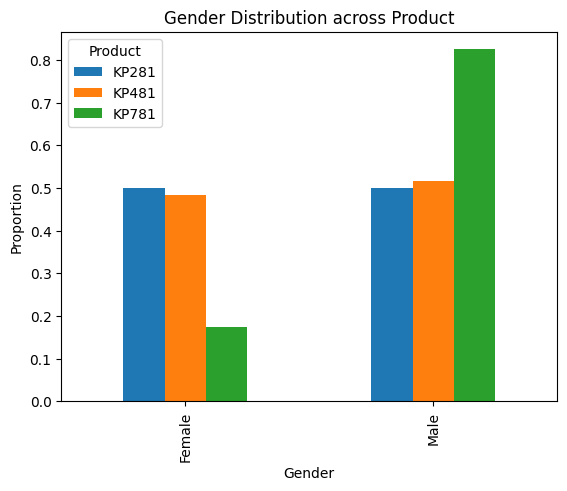

In [160]:
plot_reverse(df, 'Gender')


KP781 buyers are overwhelmingly male **(82.5%)**, while KP281 buyers are evenly split across genders, indicating that premium treadmills are strongly preferred by male customers

In [126]:
pd.crosstab(df['IncomeGroup'], df['Product'], normalize='columns') # P(Feature | Product)

Product,KP281,KP481,KP781
IncomeGroup,,,
Low,0.4875,0.4,0.0
Medium,0.3750,0.4,0.2
High,0.1375,0.2,0.8


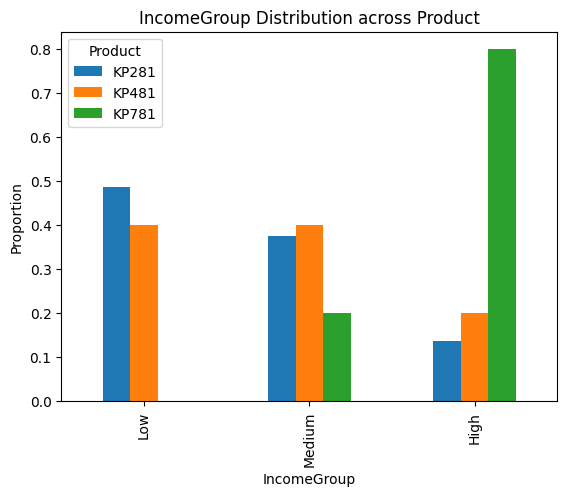

In [157]:
plot_reverse(df, 'IncomeGroup')

* **80%** of KP781 buyers belong to the high-income group*, while KP281 is dominated by low- and medium-income customers, reinforcing **strong income-based segmentation**

In [128]:
pd.crosstab(df['MilesGroup'], df['Product'], normalize='columns') # P(Feature | Product)

Product,KP281,KP481,KP781
MilesGroup,,,
Low,0.150,0.083333,0.0
Medium,0.625,0.650000,0.2
High,0.225,0.266667,0.8


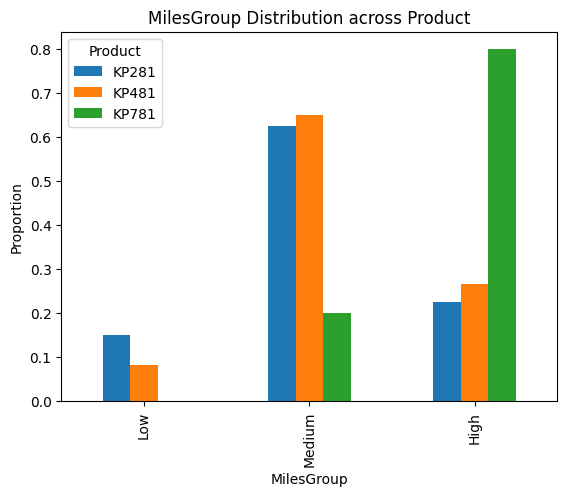

In [158]:
plot_reverse(df, 'MilesGroup')

* **80%** of KP781 buyers are high-mileage users*, whereas KP281 and KP481 are primarily purchased by medium-mileage users, highlighting **usage intensity as a key driver**.

### Multivariate Analysis

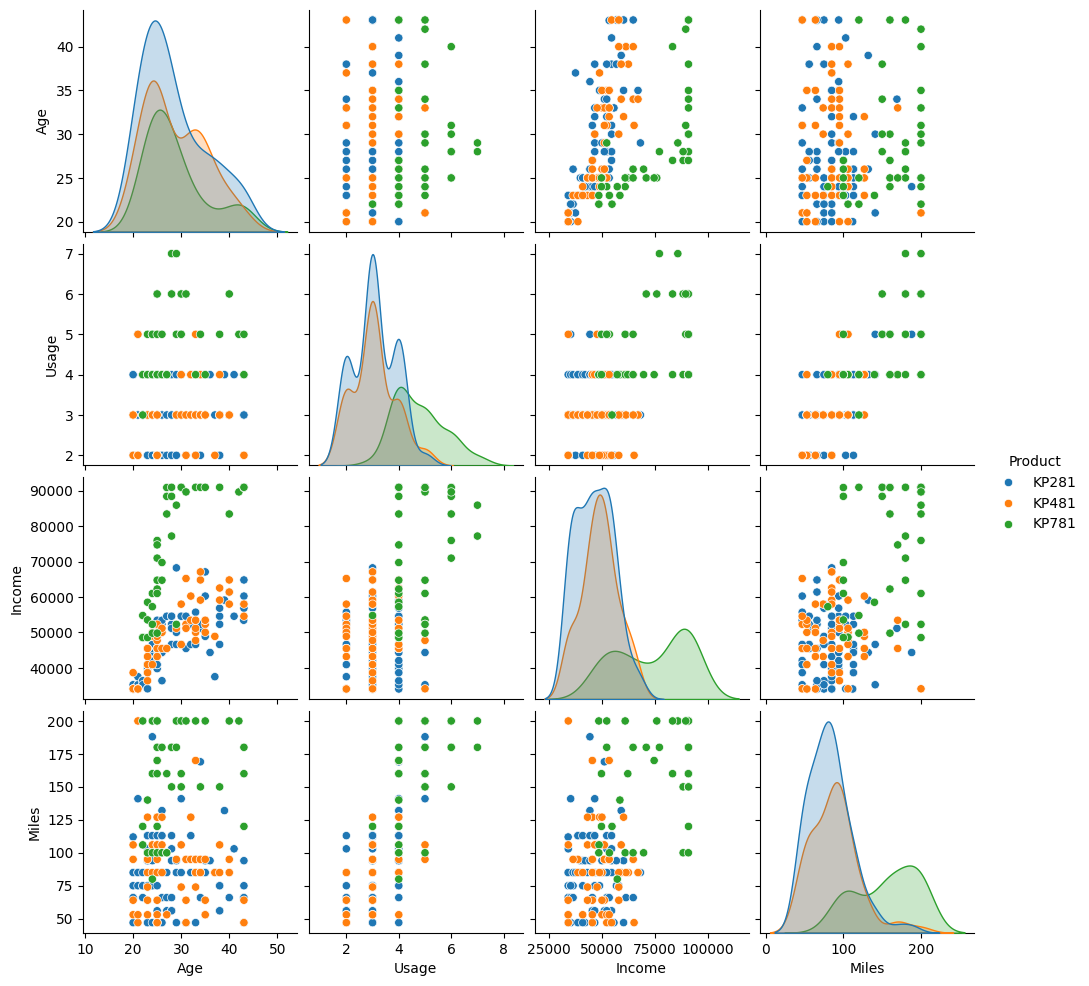

In [172]:
sns.pairplot(df, hue="Product")
plt.show()

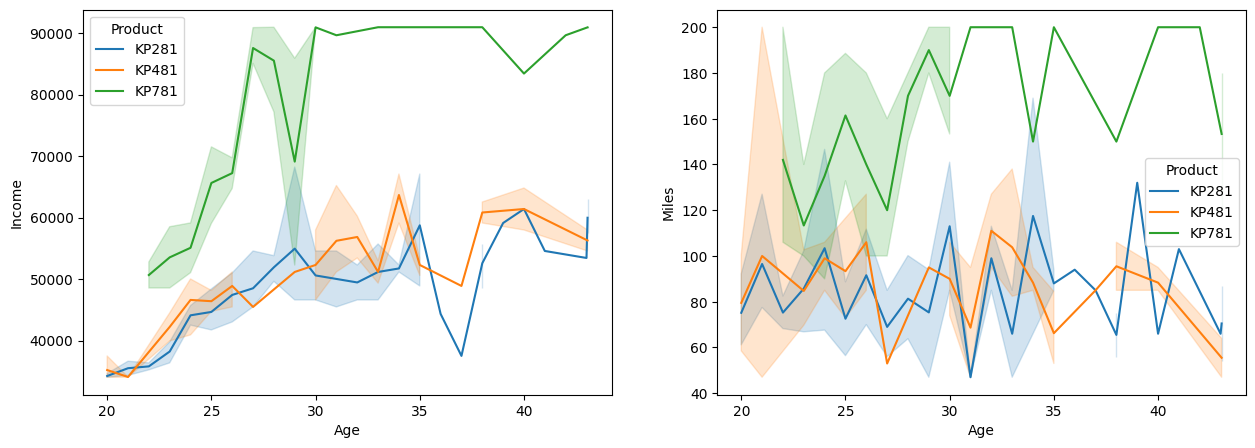

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.lineplot(x='Age', y='Income', data = df, hue = 'Product', ax=axes[0])
sns.lineplot (x='Age', y='Miles', data = df, hue = 'Product', ax=axes[1])

plt.show()

<Axes: xlabel='Age', ylabel='Miles'>

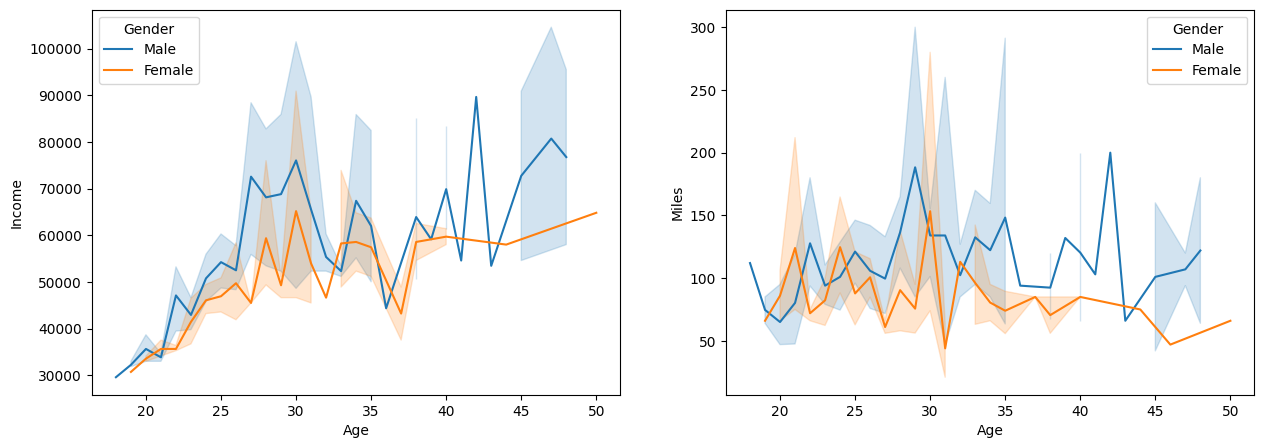

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.lineplot(x='Age', y='Income', data = df, hue = 'Gender', ax=axes[0])
sns.lineplot (x='Age', y='Miles', data = df, hue = 'Gender', ax=axes[1])

1. KP781 treadmill is being used by high-income young adults in age bracket 22-30 years.

2. As age is increasing females are clocking less miles than males. There's a considerable dip in miles run/walk from 40-50 year females.

              Age    Income     Usage   Fitness     Miles
Age      1.000000  0.514362  0.018020  0.059047  0.029636
Income   0.514362  1.000000  0.527707  0.535945  0.537297
Usage    0.018020  0.527707  1.000000  0.668606  0.786269
Fitness  0.059047  0.535945  0.668606  1.000000  0.822393
Miles    0.029636  0.537297  0.786269  0.822393  1.000000


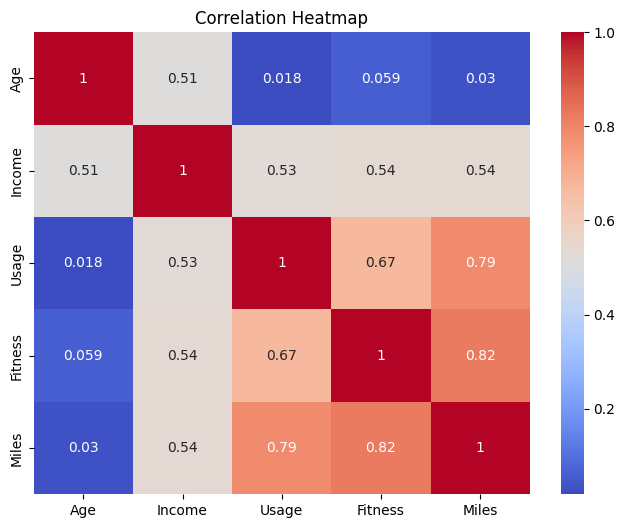

In [162]:
corr = df[['Age', 'Income', 'Usage', 'Fitness', 'Miles']].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

1. Customers who use the treadmill more frequently also tend to cover more distance, indicating consistent and predictable usage behavior.
2. Higher fitness levels are strongly associated with greater mileage, suggesting that more fit individuals engage in higher-intensity workouts.
3. Customers with higher fitness levels tend to use the treadmill more frequently, reinforcing the link between fitness and engagement.

The strong interrelationship between usage, fitness, and mileage, combined with their association with higher income, explains why premium treadmills are predominantly purchased by highly active and financially capable customers.

# Customer Segmentation & Strategic Recommendations

---

## 1. Customer Segmentation by Product

### KP281 — Mass / Entry Segment

**Customer Profile**
- Income: Low to lower-middle  
- Usage: Low to moderate  
- Mileage: Low  
- Gender: Balanced  
- Behavior: Casual / beginner users  

**Key Insight**  
KP281 is the **largest volume driver**, catering to **price-sensitive customers** with low engagement.

**Business Implication**
- High acquisition product  
- Low lifetime value unless converted  

---

### KP481 — Transitional / Undifferentiated Segment

**Customer Profile**
- Income: Middle  
- Usage: Moderate  
- Mileage: Moderate  
- Fitness: Relatively lower than expected  
- Behavior: Regular but not performance-driven  

**Key Insight**  
KP481 lacks a **clear identity**:
- Not attractive to beginners (price higher than KP281)  
- Not attractive to serious users (who skip to KP781)  

**Business Implication**
- Weak positioning  
- Potential product-market mismatch  

---

### KP781 — Premium / Performance Segment

**Customer Profile**
- Income: High  
- Usage: High  
- Mileage: High  
- Fitness: High  
- Gender: Strongly male-skewed  

**Key Insight**  
KP781 adoption is driven by:
- **Ability (income)**  
- **Need (high activity)**  
- **Preference (performance orientation)**  

**Business Implication**
- High-margin product  
- Underpenetrated in key segments (female, mid-age users)  

---

## 2. Core Business Drivers

Product choice is primarily driven by:

- **Income (financial capacity)**  
- **Usage intensity (usage, mileage, fitness)**  

### Segment Mapping

Customer segments are not strictly separated but show **probabilistic tendencies**:

| Segment            | Characteristics                                      | Product Tendency |
|------------------|------------------------------------------------------|------------------|
| Casual Users      | Low income, low usage, low mileage                  | Strongly KP281   |
| Value Seekers     | Medium income, moderate usage                       | KP281 + KP481 mix |
| Aspirational Users| Medium to high income, increasing usage             | Transition KP481 → KP781 |
| Performance Users | High income, high usage, high mileage               | Strongly KP781   |
---

## 3. Strategic Recommendations

---

### 3.1 Expand Premium Segment (KP781)

**Problem**
- Strong product fit but limited adoption  
- Low female participation  
- Weak adoption among 30–39 age group  

**Actions**
- Target **high-income, high-usage users**
- Develop **female-focused campaigns**
- Position KP781 as a **long-term fitness investment**

---

### 3.2 Fix KP481 Positioning (Critical)

**Problem**
- Lowest fitness engagement  
- Avoided by performance users  
- Weak differentiation  

**Actions**
- Conduct **customer feedback analysis**
- Reposition as:
  > “Upgrade for serious regular users”
- Improve features, pricing, and value proposition  

---

### 3.3 Build Structured Upsell Funnel

**Problem**
- Large KP281 base not monetized  

**Actions**
- Create upgrade triggers:
  - Increase in usage  
  - Increase in mileage  
  - Improvement in fitness score  

**Strategy**
- KP281 → KP481 → KP781 progression  

---

### 3.4 Grow Female Customer Segment

**Problem**
- Lower usage and mileage  
- Very low premium adoption  

**Actions**
- Improve product accessibility and comfort  
- Targeted marketing focused on health and lifestyle  
- Focus on older female segments (40+)  

---

### 3.5 Target Middle-Income Upgrade Opportunity

**Problem**
- Medium-income customers under-convert to KP781  

**Insight**
- They have **financial capacity but low conversion**

**Actions**
- Introduce financing options (EMI)  
- Highlight long-term value and benefits  

---

### 3.6 Build Data-Driven Recommendation Engine

**Recommendation Logic**

- High income + high usage → KP781  
- Medium income + increasing usage → KP481  
- Low usage → KP281  

---

## 4. Strategic Conclusion

Aerofit’s market naturally segments into **casual, regular, and performance users**, driven by:

- Income → ability to purchase  
- Usage → need for performance  

---

## 5. Executive Takeaway

Growth opportunities lie in:

- Increasing premium adoption (KP781)  
- Fixing mid-tier positioning (KP481)  
- Expanding female customer base  
- Leveraging behavioral data for personalization  

---

**Final Insight**

> Converting high-potential users upward (KP281 → KP781) and targeting underpenetrated segments will drive sustainable growth.